# Map Converter
This is a Jupyter Notebook to Convert a `.png` or `.pgm` + `.yaml` of a map into a `.csv` that can be fed into the TUMFTM functions.

High Level Steps:
1. Get the Euclidean Distance Transform of the map
2. Apply skeletonization to the map to extract centerlines
3. Run DFS to extract the centerline xy coordinates in order
4. Apply the transformations to go from pixel to meter coordinate frame


Map Conditions:
- Map edges should be well defined, inside should be white, walls are black and outside is grey

In [98]:
import numpy as np
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt
import yaml
import scipy
from scipy.ndimage import distance_transform_edt as edt
from PIL import Image
import os

In [99]:
MAP_NAME = "3_30"

TRACK_WIDTH_MARGIN = 0.1 # Extra Safety margin, in meters

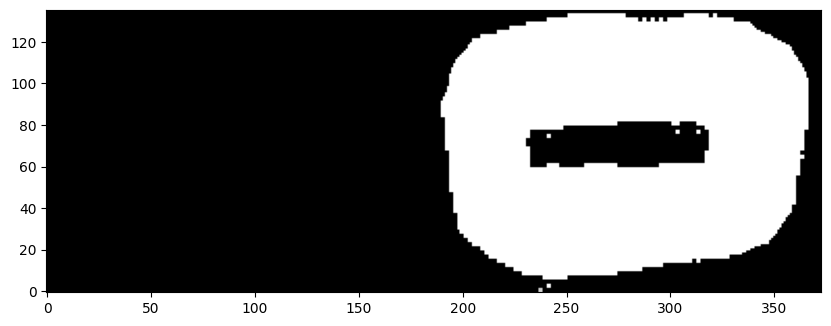

In [100]:
# Load map image

if os.path.exists(f"maps/{MAP_NAME}.png"):
    map_img_path = f"maps/{MAP_NAME}.png"
elif os.path.exists(f"maps/{MAP_NAME}.pgm"):
    map_img_path = f"maps/{MAP_NAME}.pgm"
else:
    raise Exception("Map not found!")

map_yaml_path = f"maps/{MAP_NAME}.yaml"
raw_map_img = np.array(Image.open(map_img_path).transpose(Image.FLIP_TOP_BOTTOM))
# raw_map_img = np.array(Image.open(map_img_path))
raw_map_img = raw_map_img.astype(np.float64)

plt.figure(figsize=(10, 10))
plt.imshow(raw_map_img, cmap='gray', origin='lower')

map_height = 136
map_width = 373


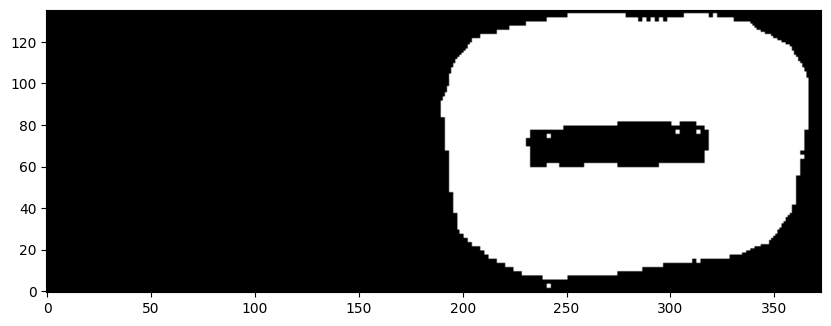

In [101]:
# grayscale -> binary. Converts grey to black
map_img = raw_map_img.copy()
map_img[map_img <= 210.] = 0
map_img[map_img > 210.] = 1

map_height = map_img.shape[0]
map_width = map_img.shape[1]
print(f'{map_height = }')
print(f'{map_width = }')
map_img
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap='gray', origin='lower')

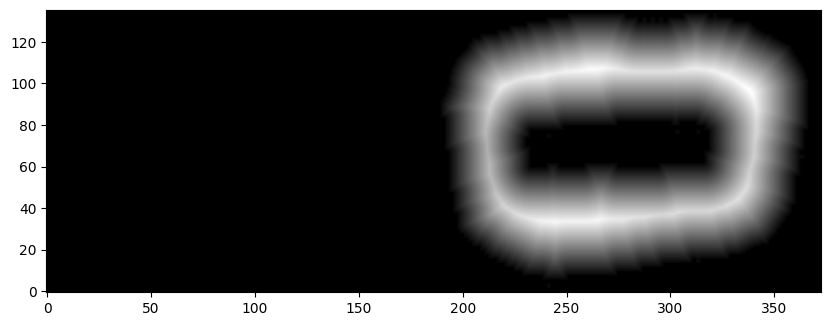

In [102]:
plt.figure(figsize=(10, 10))
# Calculate Euclidean Distance Transform (tells us distance to nearest wall)
dist_transform = scipy.ndimage.distance_transform_edt(map_img)
plt.imshow(dist_transform, cmap='gray', origin='lower')

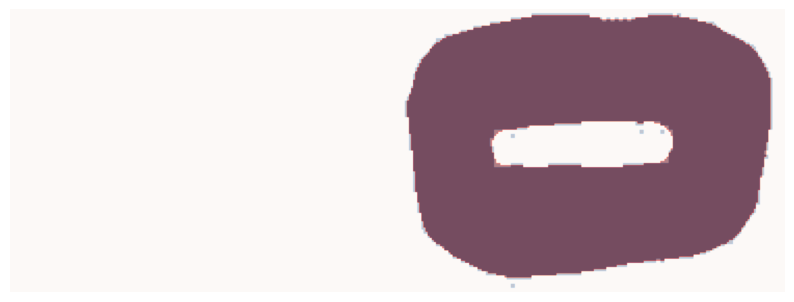

In [103]:
from skimage.morphology import (
    binary_opening, binary_closing, remove_small_objects,
    remove_small_holes, skeletonize, disk
)

# img: boolean binary image
clean = binary_closing(map_img, disk(1))   # fills tiny gaps
clean = binary_opening(clean, disk(1))     # removes tiny protrusions
clean = remove_small_objects(clean, 50)    # removes tiny blobs
clean = remove_small_holes(clean, 50)      # removes tiny holes

from skimage.filters import gaussian
smooth = gaussian(clean.astype(float), sigma=4.0) > 0.55

plt.figure(figsize=(10, 10))
plt.imshow(map_img, origin='lower', cmap='Blues', alpha=0.5)
plt.imshow(smooth, origin='lower', cmap='Reds', alpha=0.5)
plt.axis("off")
plt.show()

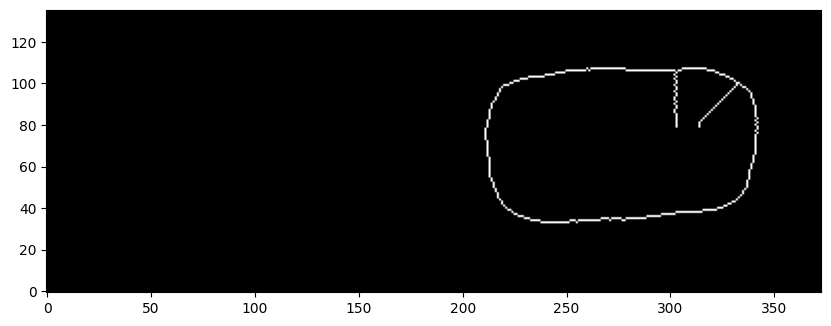

In [104]:
from skimage.morphology import medial_axis

centerline, dist_on_centerline = medial_axis(clean, return_distance=True)

plt.figure(figsize=(10, 10))
plt.imshow(centerline, origin='lower', cmap='gray')

In [105]:

# Threshold the distance transform to create a binary image

# THRESHOLD = 0.1 # You should play around with this number. Is you say hairy lines generated, either clean the map so it is more curvy or increase this number
# centers = (dist_transform > THRESHOLD*dist_transform.max()).astype(np.uint8)
# plt.figure(figsize=(10, 10))
# plt.imshow(centers, origin='lower', cmap='gray')

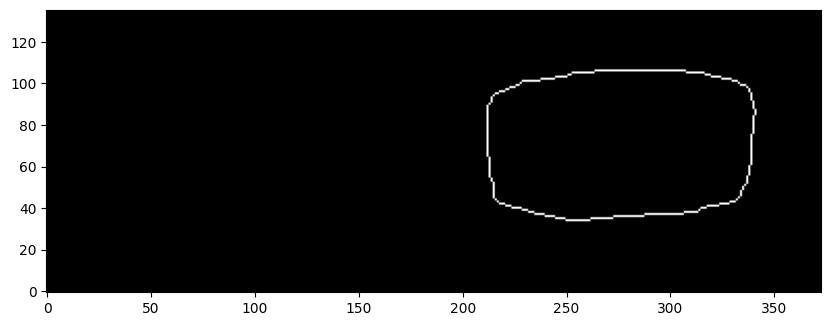

In [106]:
plt.figure(figsize=(10, 10))
centerline = skeletonize(clean)
plt.imshow(centerline, origin='lower', cmap='gray')

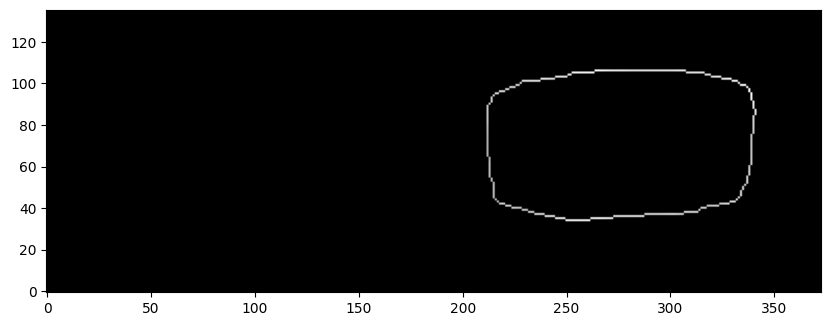

In [107]:
# The centerline has the track width encoded
plt.figure(figsize=(10, 10))
centerline_dist = np.where(centerline, dist_transform, 0)
plt.imshow(centerline_dist, origin='lower', cmap='gray')

In [ ]:
NON_EDGE = 0.0
# Use DFS to extract the outer edge
left_start_y = map_height // 2
left_start_x = 0
while (centerline_dist[left_start_y][left_start_x] == NON_EDGE): 
	left_start_x += 1

print(f"Starting position for left edge: {left_start_x} {left_start_y}")

IndexError: index 373 is out of bounds for axis 0 with size 373

In [ ]:
# Run DFS
import sys
sys.setrecursionlimit(20000)

visited = {}
centerline_points = []
track_widths = []
# DIRECTIONS = [(0, 1), (1, 0), (0, -1), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)]
# If you want the other direction first
DIRECTIONS = [(0, -1), (-1, 0),  (0, 1), (1, 0), (-1, 1), (-1, -1), (1, 1), (1, -1) ]

starting_point = (left_start_x, left_start_y)

def dfs(point):
	if (point in visited): return
	visited[point] = True
	centerline_points.append(np.array(point))
	track_widths.append(np.array([centerline_dist[point[1]][point[0]], centerline_dist[point[1]][point[0]]]))

	for direction in DIRECTIONS:
		if (centerline_dist[point[1] + direction[1]][point[0] + direction[0]] != NON_EDGE and (point[0] + direction[0], point[1] + direction[1]) not in visited):
			dfs((point[0] + direction[0], point[1] + direction[1]))

dfs(starting_point)

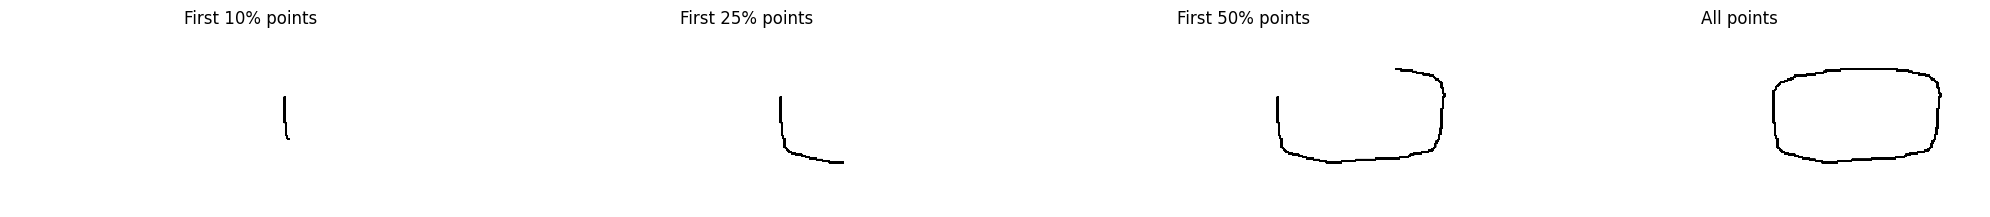

In [ ]:
fig, (ax1,ax2,ax3, ax4) = plt.subplots(1, 4, figsize=(20,5))
ax1.axis('off')
ax2.axis('off')
ax3.axis('off')
ax4.axis('off')

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points[:len(centerline_points)//10]:
	centerline_img[y][x] = 255
ax1.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax1.set_title("First 10% points")

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points[:len(centerline_points)//4]:
	centerline_img[y][x] = 255
ax2.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax2.set_title("First 25% points")

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points[:int(len(centerline_points)/1.4)]:
	centerline_img[y][x] = 255
ax3.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax3.set_title("First 50% points")

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points:
	centerline_img[y][x] = 1000
ax4.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax4.set_title("All points")
fig.tight_layout()

# Conversion
Convert into Pandas, and go from pixels to meters, and then shift by the origin.

In [ ]:
track_widths

[array([21.02379604, 21.02379604]),
 array([21., 21.]),
 array([21., 21.]),
 array([20.61552813, 20.61552813]),
 array([20.24845673, 20.24845673]),
 array([19.92485885, 19.92485885]),
 array([19.6468827, 19.6468827]),
 array([19.41648784, 19.41648784]),
 array([19.23538406, 19.23538406]),
 array([19.10497317, 19.10497317]),
 array([19.02629759, 19.02629759]),
 array([19., 19.]),
 array([19., 19.]),
 array([19., 19.]),
 array([19., 19.]),
 array([19.02629759, 19.02629759]),
 array([19.02629759, 19.02629759]),
 array([19., 19.]),
 array([19., 19.]),
 array([19., 19.]),
 array([18.97366596, 18.97366596]),
 array([19.31320792, 19.31320792]),
 array([19.6977156, 19.6977156]),
 array([20., 20.]),
 array([20., 20.]),
 array([20., 20.]),
 array([20., 20.]),
 array([20., 20.]),
 array([20., 20.]),
 array([19.6977156, 19.6977156]),
 array([19.92485885, 19.92485885]),
 array([19.92485885, 19.92485885]),
 array([19.6977156, 19.6977156]),
 array([20.1246118, 20.1246118]),
 array([20.22374842, 20.22

In [ ]:
track_widths_np = np.array(track_widths)
waypoints = np.array(centerline_points)
print(f"Track widths shape: {track_widths_np.shape}, waypoints shape: {waypoints.shape}")

Track widths shape: (339, 2), waypoints shape: (339, 2)


In [ ]:
# Merge track with waypoints
data = np.concatenate((waypoints, track_widths_np), axis=1)
data.shape

(339, 4)

In [ ]:
# load map yaml
with open(map_yaml_path, 'r') as yaml_stream:
    try:
        map_metadata = yaml.safe_load(yaml_stream)
        map_resolution = map_metadata['resolution']
        origin = map_metadata['origin']
    except yaml.YAMLError as ex:
        print(ex)

# calculate map parameters
orig_x = origin[0]
orig_y = origin[1]

# get the distance transform
transformed_data = data
transformed_data *= map_resolution
transformed_data += np.array([orig_x, orig_y, 0, 0])

# Safety margin
transformed_data -= np.array([0, 0, TRACK_WIDTH_MARGIN, TRACK_WIDTH_MARGIN])

In [ ]:
# Uncomment this if you get the following error: raise IOError("At least two spline normals are crossed, check input or increase smoothing factor!")
# transformed_data = transformed_data[::4]

In [ ]:
with open(f"inputs/tracks/{MAP_NAME}.csv", 'wb') as fh:
    np.savetxt(fh, transformed_data, fmt='%0.4f', delimiter=',', header='x_m,y_m,w_tr_right_m,w_tr_left_m')

Next up, check out `sanity_check.ipynb` to make sure that the centerline generated lines up with the map.